In [1]:
import numpy as np
from netCDF4 import Dataset, MFDataset
import matplotlib.pyplot as plt
import os, glob
from datetime import datetime, timedelta
import pandas as pd

`get_dates_list(day0,dates_back)`:

Get a list of dates between the forecast date (`day0`) and `dates_back` (default is 1). Dates are given in `%Y%m%d%H` format to match TCFP formatting. 

<b>Inputs:</b>
* `day0`: Target date [string, `%Y%m%d%H`]
* `dates_back`: How many days back are we looking? [int, default is 1]

<b>Outputs:</b>
* `list_dates`: List of dates (in `%Y%m%d%H` format) between `day0` and `dates_back` days earlier [list of strings]

In [2]:
def get_dates_list(day0,dates_back=1):
    date1 = datetime.strptime(day0,'%Y%m%d%H')
    date2 = date1 - timedelta(days=dates_back)
    hrs_back = dates_back*24
    # print(hrs_back)
    # Get list of dates for every 6 hours
    list_dates = []
    for singledate in (date1 - timedelta(hours=n) for n in range(0,hrs_back+1,6)):
        list_dates.append(datetime.strftime(singledate,'%Y%m%d%H'))
    return list_dates   

Read in Marshall's labels for one year (2020)

For each day, calculate the number of points that are "yes" for TC genesis for the past [1,5] days

In [11]:
label_dir = ('/mnt/ssd1/mbaldwin/12hr_genesis_labels/')
yr_ALL = [2015,2016,2017,2018,2019,2020,2021]
#year_sel = 2020
genesis_pct_by_year_5day = pd.DataFrame()
genesis_pct_by_year_1day = pd.DataFrame()
genesis_pct_by_year_7day = pd.DataFrame()

In [12]:
for year_sel in yr_ALL:
    fnames_labels = glob.glob(label_dir+'{yr}/*.nc'.format(yr=year_sel))
    genesis_pct = pd.DataFrame(columns=['Forecast Date','No. Positive','No. Total'],index=np.arange(0,len(fnames_labels)))
    genesis_pct7 = pd.DataFrame(columns=['Forecast Date','No. Positive','No. Total'],index=np.arange(0,len(fnames_labels)))
    genesis_pct1 = pd.DataFrame(columns=['Forecast Date','No. Positive','No. Total'],index=np.arange(0,len(fnames_labels)))
    # 
    print('year is ',year_sel)
    for i in np.arange(0,len(fnames_labels)):
        ex = fnames_labels[i]
        exdate = ex[70:80]
        #print('running ',exdate)
        date1 = datetime.strptime(exdate,'%Y%m%d%H')
        list_of_dates = get_dates_list(exdate,5)
        all_pos = []
        all_total = []
        for idate in list_of_dates:
            matching = [x for x in fnames_labels if idate in x]
            if not matching:
                continue
            else:
                labels = Dataset(matching[0]).variables['gen_label']
                no_positive =  len(np.where(labels[:] > 0)[0])
                all_pos.append(no_positive)
                no_total = labels[:].size
                all_total.append(no_total)
            # pct_gen = no_positive/no_total
        genesis_pct.loc[i,'Forecast Date'] = exdate
        genesis_pct.loc[i,'No. Positive'] = np.sum(all_pos)
        genesis_pct.loc[i,'No. Total'] = np.sum(all_total)
        genesis_pct['Percentage'] = 100*(genesis_pct['No. Positive']/genesis_pct['No. Total'])
        genesis_pct['No Days'] = 5
        genesis_pct['Year'] = year_sel
        #
        list_of_dates_7day = get_dates_list(exdate,7)
        all_pos = []
        all_total = []
        for idate7 in list_of_dates_7day:
            matching = [x for x in fnames_labels if idate7 in x]
            if not matching:
                continue
            else:
                labels = Dataset(matching[0]).variables['gen_label']
                no_positive =  len(np.where(labels[:] > 0)[0])
                all_pos.append(no_positive)
                no_total = labels[:].size
                all_total.append(no_total)
            # pct_gen = no_positive/no_total
        genesis_pct7.loc[i,'Forecast Date'] = exdate
        genesis_pct7.loc[i,'No. Positive'] = np.sum(all_pos)
        genesis_pct7.loc[i,'No. Total'] = np.sum(all_total)
        genesis_pct7['Percentage'] = 100*(genesis_pct7['No. Positive']/genesis_pct7['No. Total'])
        genesis_pct7['No Days'] = 7
        genesis_pct7['Year'] = year_sel
        #
        list_of_dates_1day = get_dates_list(exdate,1)
        all_pos = []
        all_total = []
        for idate1 in list_of_dates_1day:
            matching = [x for x in fnames_labels if idate1 in x]
            if not matching:
                continue
            else:
                labels = Dataset(matching[0]).variables['gen_label']
                no_positive =  len(np.where(labels[:] > 0)[0])
                all_pos.append(no_positive)
                no_total = labels[:].size
                all_total.append(no_total)
            # pct_gen = no_positive/no_total
        genesis_pct1.loc[i,'Forecast Date'] = exdate
        genesis_pct1.loc[i,'No. Positive'] = np.sum(all_pos)
        genesis_pct1.loc[i,'No. Total'] = np.sum(all_total)
        genesis_pct1['Percentage'] = 100*(genesis_pct1['No. Positive']/genesis_pct1['No. Total'])
        genesis_pct1['No Days'] = 1
        genesis_pct1['Year'] = year_sel
    genesis_pct_by_year_5day = pd.concat([genesis_pct_by_year_5day,genesis_pct])
    genesis_pct_by_year_7day = pd.concat([genesis_pct_by_year_7day,genesis_pct7])
    genesis_pct_by_year_1day = pd.concat([genesis_pct_by_year_1day,genesis_pct1])    

year is  2015
year is  2016
year is  2017
year is  2018
year is  2019
year is  2020
year is  2021


In [13]:
genesis_pct_comb = pd.concat([genesis_pct_by_year_5day,genesis_pct_by_year_7day,genesis_pct_by_year_1day])

Text(0, 0.5, 'Percentage of Positive Labels')

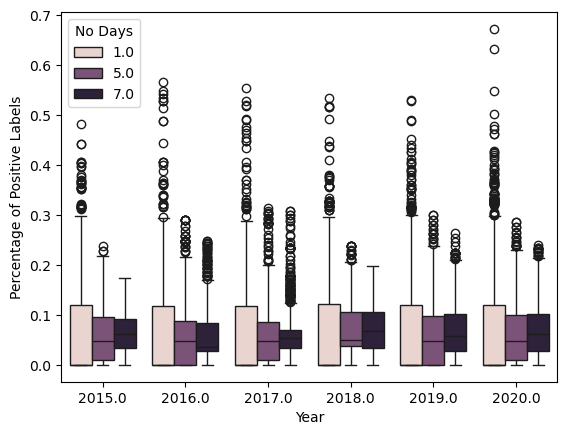

In [14]:
import seaborn as sns
sns.boxplot(data=genesis_pct_comb,x='Year',y='Percentage',hue='No Days')
plt.ylabel('Percentage of Positive Labels')